# Multiclass Classification with Spark Batch Trainer

This notebook compares **XGBoost**, **CatBoost**, and **LightGBM** on a seven-class obesity dataset. It demonstrates the complete multiclass workflow with the current package architecture and public API.

## Learning objectives

- inspect and validate a multiclass dataset;
- encode the target without leaking information from validation or test;
- create reproducible stratified splits;
- configure all three backends for multiclass objectives;
- compare class-level errors and probability quality; and
- interpret confidence without treating confidence as calibration.

> **Terminology:** this is multiclass classification—one target and one class per observation—not multilabel classification.

## Phase 1 — Environment and reproducibility

Resolve the repository root explicitly so the notebook behaves the same from the project root and the `notebooks/` directory.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """Return the nearest parent containing pyproject.toml."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate pyproject.toml from the current directory.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_PATH = PROJECT_ROOT / "src"
for import_path in (PROJECT_ROOT, SRC_PATH):
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/surelmanda/3-Mlops-Databricks-Projects/SparkBatchTrainer


In [2]:
import warnings
import pandas as pd
import seaborn as sns
from IPython.display import display
from pyspark.sql import SparkSession

from utils import (
    load_dataset,
    preprocess_splits,
    stratified_split_dataset,
    plot_multiclass_confusion_matrices,
    get_dataset_path,
    plot_class_distribution,
)

from spark_batch_trainer import CatBoostTrainer
from spark_batch_trainer import XGBoostTrainer
from spark_batch_trainer import LightGBMTrainer



warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
TARGET_COLUMN = "NObeyesdad"

## Phase 2 — Load and understand the dataset

Validate the target and basic schema before encoding labels. Class frequency matters because overall accuracy can hide weak performance on smaller classes.

In [3]:
dataset_path = get_dataset_path("data/multiclass_dataset")

print("Loading dataset...")
print("Dataset path:", dataset_path)
dataset = load_dataset(dataset_path)

assert TARGET_COLUMN in dataset.columns, f"Missing target column: {TARGET_COLUMN}"
assert dataset[TARGET_COLUMN].nunique() > 2, "A multiclass target was expected."
assert not dataset.columns.duplicated().any(), "Duplicate column names detected."

quality_summary = pd.DataFrame(
    {
        "rows": [len(dataset)],
        "features": [dataset.shape[1] - 1],
        "classes": [dataset[TARGET_COLUMN].nunique()],
        "missing_values": [int(dataset.isna().sum().sum())],
        "duplicate_rows": [int(dataset.duplicated().sum())],
    }
)
#display(quality_summary)
display(dataset.head())
print(f"row count: {dataset.shape[0]}, features: {dataset.shape[1] - 1}, classes: {dataset[TARGET_COLUMN].nunique()}")

Loading dataset...
Dataset path: /Users/surelmanda/3-Mlops-Databricks-Projects/SparkBatchTrainer/data/multiclass_dataset/ObesityDataset.csv


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


row count: 2111, features: 16, classes: 7


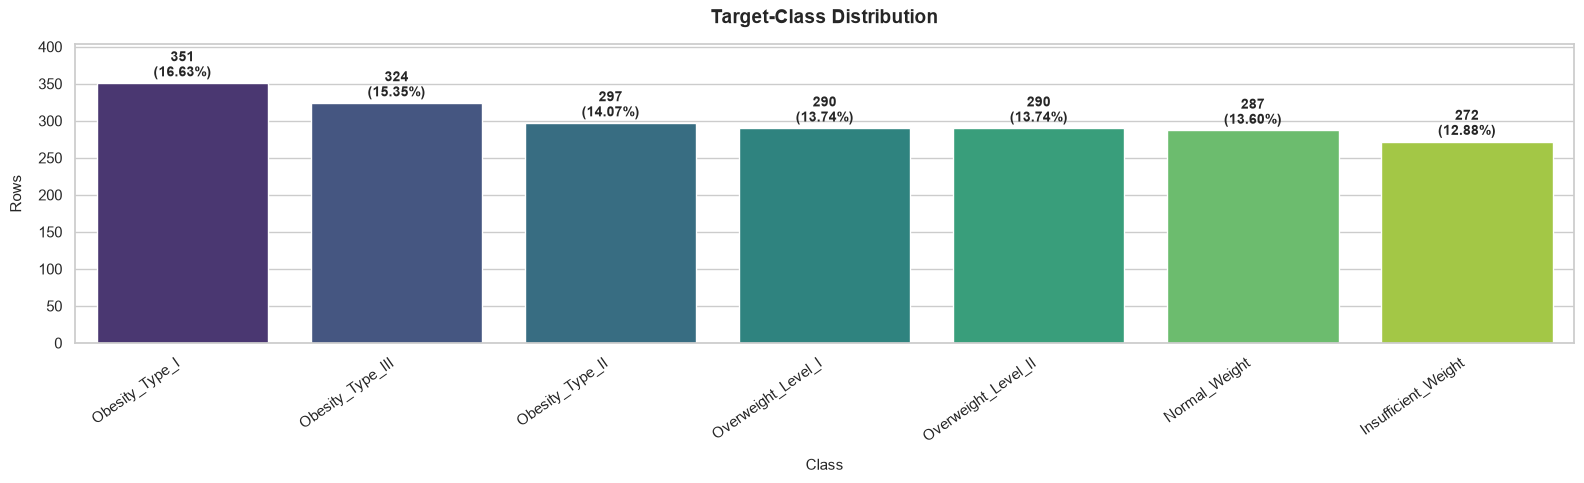

In [4]:
dist_df = plot_class_distribution(dataset, TARGET_COLUMN, figsize=(16, 5))

### Interpretation checkpoint

Review whether every class has enough observations for all three splits. If one class is rare, prefer balanced accuracy and per-class recall over overall accuracy alone.

## Phase 3 — Stratified splitting and target encoding

Split first, then fit the label encoder on the training target only. Transform validation and test with the same mapping so class identifiers remain stable.

In [5]:
train_df, validation_df, test_df = stratified_split_dataset(
    dataset,
    target_column=TARGET_COLUMN,
    train_ratio=0.70,
    valid_ratio=0.15,
    test_ratio=0.15,
    random_state=RANDOM_STATE,
)

splits, label_encoder = preprocess_splits(
    train_df, validation_df, test_df,
    target_column=TARGET_COLUMN,
    y_dtype="int",
    auto_encode_target=True,
)
X_train, y_train = splits.X_train, splits.y_train
X_valid, y_valid = splits.X_valid, splits.y_valid
X_test, y_test = splits.X_test, splits.y_test

CLASS_NAMES = label_encoder.classes_.tolist()
NUMBER_OF_CLASSES = len(CLASS_NAMES)
CLASS_IDS = list(range(NUMBER_OF_CLASSES))

mapping = pd.DataFrame({"class_id": CLASS_IDS, "class_name": CLASS_NAMES})
display(mapping)

,class_id,class_name
0,0,Insufficient_Weight
1,1,Normal_Weight
2,2,Obesity_Type_I
3,3,Obesity_Type_II
4,4,Obesity_Type_III
5,5,Overweight_Level_I
6,6,Overweight_Level_II


In [6]:
split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(frame),
            "classes": frame[TARGET_COLUMN].nunique(),
        }
        for name, frame in (
            ("train", train_df),
            ("validation", validation_df),
            ("test", test_df),
        )
    ]
)
assert split_summary["classes"].eq(NUMBER_OF_CLASSES).all()
display(split_summary)

,split,rows,classes
0,train,1477,7
1,validation,317,7
2,test,317,7


## Phase 4 — Start Spark and create trainer inputs

The trainer receives Spark DataFrames. The untouched test set remains in pandas for final native-model evaluation.

In [7]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("SparkBatchTrainerMulticlassGuide")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

spark_train_df = spark.createDataFrame(
    pd.concat([X_train, y_train.rename(TARGET_COLUMN)], axis=1)
)
spark_validation_df = spark.createDataFrame(
    pd.concat([X_valid, y_valid.rename(TARGET_COLUMN)], axis=1)
)

print(f"Spark version: {spark.version}")
print(f"Training rows: {spark_train_df.count():,}")
print(f"Validation rows: {spark_validation_df.count():,}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/05 08:03:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.2


Training rows: 1,477


Validation rows: 317


## Phase 5 — Shared controls and evaluation helpers

Multiclass log loss is minimized. Balanced accuracy is included in the final comparison to give every class equal importance.

In [8]:
TRAINING_CONFIG = {
    "num_batches": 5,
    "max_patience": 3,
    "metric_mode": "min",
    "min_delta": 1e-4,
    "use_sample_weight": False,
    "show_learning_curve": False,
}

LEARNING_RATE_CONFIG = {
    "initial_lr": 0.05,
    "decay_rate": 0.95,
    "min_lr": 0.005,
}

In [9]:
def summarize_history(trainer) -> pd.DataFrame:
    """Return the last train and validation metric recorded per batch."""
    history = trainer.get_training_history()
    return pd.DataFrame(
        {
            "batch": history.batch_numbers,
            "train_metric": [values[-1] for values in history.train_scores],
            "validation_metric": [
                values[-1] for values in history.validation_scores
            ],
        }
    )

## Phase 6 — Train XGBoost

`multi:softprob` produces class probabilities, which are required for multiclass log loss and confidence analysis.

Importing XGBoostTrainer...
XGBoostTrainer instantiated successfully


[0]	validation_0-mlogloss:1.86329	validation_1-mlogloss:1.87660
[1]	validation_0-mlogloss:1.79049	validation_1-mlogloss:1.81568
[2]	validation_0-mlogloss:1.72410	validation_1-mlogloss:1.76051
[3]	validation_0-mlogloss:1.65630	validation_1-mlogloss:1.70062
[4]	validation_0-mlogloss:1.60360	validation_1-mlogloss:1.65765
[5]	validation_0-mlogloss:1.54679	validation_1-mlogloss:1.61357
[6]	validation_0-mlogloss:1.49073	validation_1-mlogloss:1.56925
[7]	validation_0-mlogloss:1.43937	validation_1-mlogloss:1.52871
[8]	validation_0-mlogloss:1.38831	validation_1-mlogloss:1.48437
[9]	validation_0-mlogloss:1.33926	validation_1-mlogloss:1.44466
[10]	validation_0-mlogloss:1.29745	validation_1-mlogloss:1.41393
[11]	validation_0-mlogloss:1.25082	validation_1-mlogloss:1.37399
[12]	validation_0-mlogloss:1.20729	validation_1-mlogloss:1.33922
[13]	validation_0-mlogloss:1.16647	validation_1-mlogloss:1.30464
[14]	validation_0-mlogloss:1.12731	validation_1-mlogloss:1.27011
[15]	validation_0-mlogloss:1.09732	

[0]	validation_0-mlogloss:0.45165	validation_1-mlogloss:0.50252
[1]	validation_0-mlogloss:0.44269	validation_1-mlogloss:0.49838
[2]	validation_0-mlogloss:0.43277	validation_1-mlogloss:0.49401
[3]	validation_0-mlogloss:0.42368	validation_1-mlogloss:0.49078
[4]	validation_0-mlogloss:0.41387	validation_1-mlogloss:0.48592
[5]	validation_0-mlogloss:0.40533	validation_1-mlogloss:0.48209
[6]	validation_0-mlogloss:0.39618	validation_1-mlogloss:0.47763
[7]	validation_0-mlogloss:0.38965	validation_1-mlogloss:0.47544
[8]	validation_0-mlogloss:0.38254	validation_1-mlogloss:0.47189
[9]	validation_0-mlogloss:0.37664	validation_1-mlogloss:0.46989
[10]	validation_0-mlogloss:0.37023	validation_1-mlogloss:0.46699
[11]	validation_0-mlogloss:0.36304	validation_1-mlogloss:0.46285
[12]	validation_0-mlogloss:0.35619	validation_1-mlogloss:0.45964
[13]	validation_0-mlogloss:0.34987	validation_1-mlogloss:0.45836
[14]	validation_0-mlogloss:0.34363	validation_1-mlogloss:0.45556
[15]	validation_0-mlogloss:0.33732	

[0]	validation_0-mlogloss:0.31892	validation_1-mlogloss:0.35094
[1]	validation_0-mlogloss:0.31388	validation_1-mlogloss:0.34953
[2]	validation_0-mlogloss:0.30874	validation_1-mlogloss:0.34847
[3]	validation_0-mlogloss:0.30391	validation_1-mlogloss:0.34727
[4]	validation_0-mlogloss:0.29896	validation_1-mlogloss:0.34637
[5]	validation_0-mlogloss:0.29443	validation_1-mlogloss:0.34516
[6]	validation_0-mlogloss:0.28976	validation_1-mlogloss:0.34398
[7]	validation_0-mlogloss:0.28531	validation_1-mlogloss:0.34280
[8]	validation_0-mlogloss:0.28142	validation_1-mlogloss:0.34201
[9]	validation_0-mlogloss:0.27778	validation_1-mlogloss:0.34103
[10]	validation_0-mlogloss:0.27356	validation_1-mlogloss:0.34005
[11]	validation_0-mlogloss:0.26989	validation_1-mlogloss:0.33924
[12]	validation_0-mlogloss:0.26567	validation_1-mlogloss:0.33793
[13]	validation_0-mlogloss:0.26206	validation_1-mlogloss:0.33689
[14]	validation_0-mlogloss:0.25823	validation_1-mlogloss:0.33582
[15]	validation_0-mlogloss:0.25422	

[0]	validation_0-mlogloss:0.29044	validation_1-mlogloss:0.29804
[1]	validation_0-mlogloss:0.28607	validation_1-mlogloss:0.29720
[2]	validation_0-mlogloss:0.28199	validation_1-mlogloss:0.29531
[3]	validation_0-mlogloss:0.27782	validation_1-mlogloss:0.29372
[4]	validation_0-mlogloss:0.27426	validation_1-mlogloss:0.29182
[5]	validation_0-mlogloss:0.27058	validation_1-mlogloss:0.29093
[6]	validation_0-mlogloss:0.26667	validation_1-mlogloss:0.28949
[7]	validation_0-mlogloss:0.26310	validation_1-mlogloss:0.28830
[8]	validation_0-mlogloss:0.25936	validation_1-mlogloss:0.28743
[9]	validation_0-mlogloss:0.25643	validation_1-mlogloss:0.28632
[10]	validation_0-mlogloss:0.25333	validation_1-mlogloss:0.28526
[11]	validation_0-mlogloss:0.25028	validation_1-mlogloss:0.28434
[12]	validation_0-mlogloss:0.24674	validation_1-mlogloss:0.28329
[13]	validation_0-mlogloss:0.24397	validation_1-mlogloss:0.28253
[14]	validation_0-mlogloss:0.24096	validation_1-mlogloss:0.28157
[15]	validation_0-mlogloss:0.23748	

[0]	validation_0-mlogloss:0.18773	validation_1-mlogloss:0.24292
[1]	validation_0-mlogloss:0.18591	validation_1-mlogloss:0.24212
[2]	validation_0-mlogloss:0.18341	validation_1-mlogloss:0.24174
[3]	validation_0-mlogloss:0.18129	validation_1-mlogloss:0.24105
[4]	validation_0-mlogloss:0.17930	validation_1-mlogloss:0.24043
[5]	validation_0-mlogloss:0.17732	validation_1-mlogloss:0.24023
[6]	validation_0-mlogloss:0.17529	validation_1-mlogloss:0.23996
[7]	validation_0-mlogloss:0.17329	validation_1-mlogloss:0.23937
[8]	validation_0-mlogloss:0.17094	validation_1-mlogloss:0.23886
[9]	validation_0-mlogloss:0.16895	validation_1-mlogloss:0.23797
[10]	validation_0-mlogloss:0.16688	validation_1-mlogloss:0.23759
[11]	validation_0-mlogloss:0.16491	validation_1-mlogloss:0.23732
[12]	validation_0-mlogloss:0.16300	validation_1-mlogloss:0.23670
[13]	validation_0-mlogloss:0.16123	validation_1-mlogloss:0.23632
[14]	validation_0-mlogloss:0.15959	validation_1-mlogloss:0.23604
[15]	validation_0-mlogloss:0.15762	

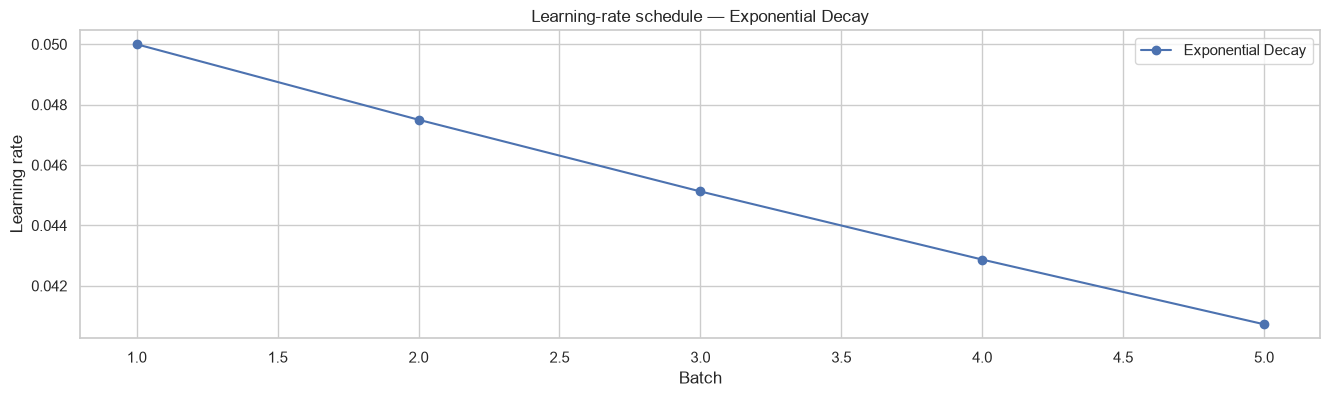

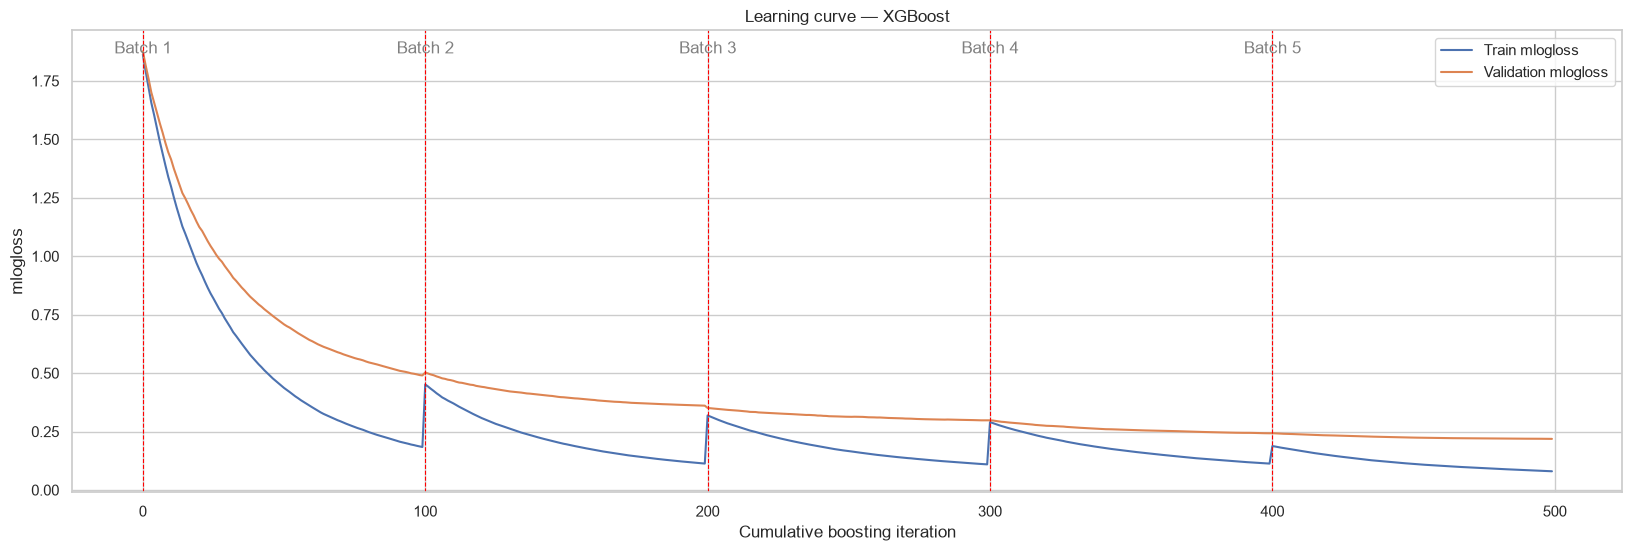

,batch,train_metric,validation_metric
0,1,0.183788,0.490032
1,2,0.113040,0.360704
2,3,0.109604,0.298055
3,4,0.112951,0.242592
4,5,0.080071,0.218625


In [10]:
print("Importing XGBoostTrainer...")
xgboost_trainer = XGBoostTrainer()
print("XGBoostTrainer instantiated successfully")

xgboost_trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_validation_df,
    target_column=TARGET_COLUMN,
    model_config={
        "objective": "multi:softprob",
        "num_class": NUMBER_OF_CLASSES,
        "eval_metric": "mlogloss",
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 6,
        "reg_lambda": 3.0,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": RANDOM_STATE,
    },
    training_config={
        **TRAINING_CONFIG,
        "max_patience": 2,
        "use_sample_weight": True,
        "show_learning_curve": True,
    },
    learning_rate_config=LEARNING_RATE_CONFIG,
)
xgboost_model = xgboost_trainer.get_trained_model()
display(summarize_history(xgboost_trainer))


########################## STARTING MODEL EVALUATION ###########################

[EVAL] Generating predictions on validation and test datasets...
[EVAL] Plotting comparative multiclass confusion matrices...


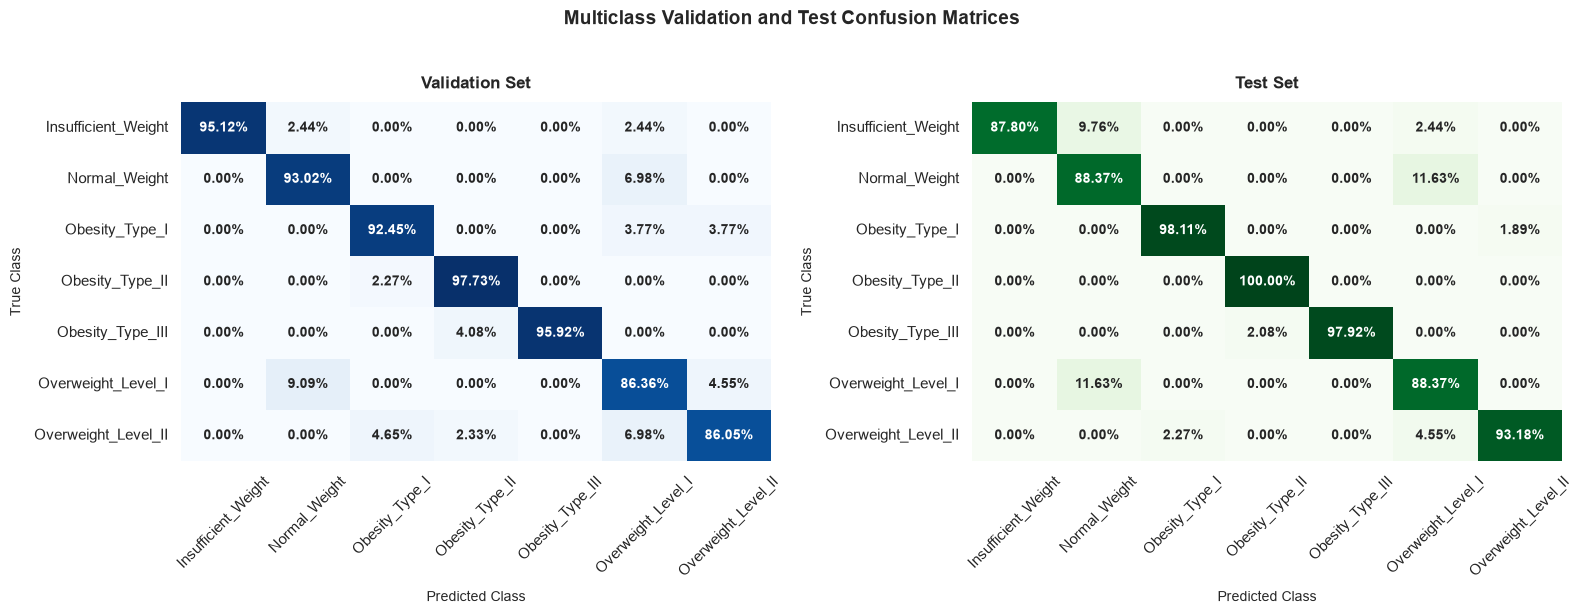


--------------------------------------------------------------------------------
-------------------------- MODEL EVALUATION COMPLETED --------------------------
--------------------------------------------------------------------------------



In [11]:
# ==============================================================================
# 1. MODEL EXTRACTION
# ==============================================================================
print("\n" + "="*80)
print(" STARTING MODEL EVALUATION ".center(80, "#"))
print("="*80 + "\n")

# Retrieve the fully trained XGBoost pipeline artifact
final_model = xgboost_trainer.get_trained_model()

# ==============================================================================
# 2. MULTICLASS PREDICTIONS
# ==============================================================================
print("[EVAL] Generating predictions on validation and test datasets...")
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# ==============================================================================
# 3. VISUALIZATION (MULTICLASS CONFUSION MATRICES)
# ==============================================================================
print("[EVAL] Plotting comparative multiclass confusion matrices...")
plot_multiclass_confusion_matrices(
    y_true_valid=y_valid,
    y_pred_valid=y_pred_valid,
    y_true_test=y_test,
    y_pred_test=y_pred_test,
    mapping_df=mapping,  # Dynamically maps and sorts class IDs and names
    normalize=True       # Normalizes values to display percentages (%)
)

print("\n" + "-"*80)
print(" MODEL EVALUATION COMPLETED ".center(80, "-"))
print("-"*80 + "\n")

## Phase 7 — Train CatBoost

CatBoost uses its native multiclass objective. File output is disabled to keep notebook runs free of generated training directories.

Importing CatBoostTrainer...
CatBoostTrainer instantiated successfully


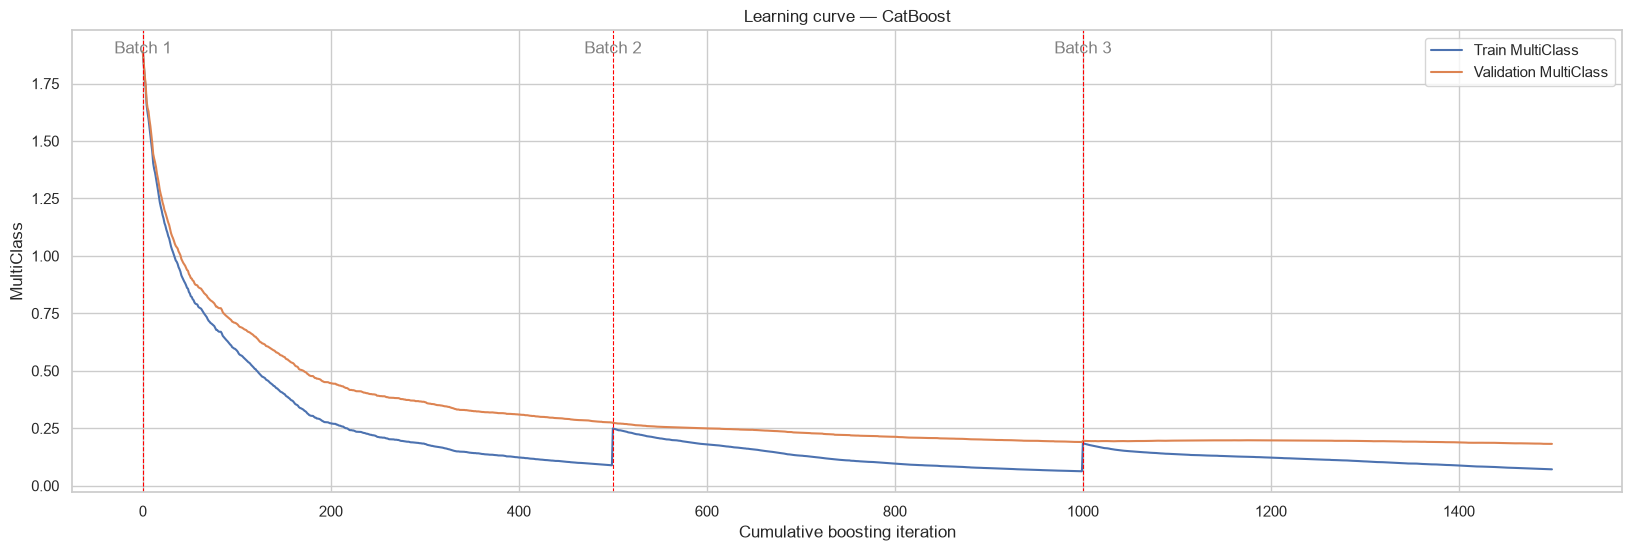

,batch,train_metric,validation_metric
0,1,0.088803,0.274965
1,2,0.062765,0.190182
2,3,0.071257,0.181991


In [12]:
print("Importing CatBoostTrainer...")
catboost_trainer = CatBoostTrainer()
print("CatBoostTrainer instantiated successfully")

catboost_trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_validation_df,
    target_column=TARGET_COLUMN,
    model_config={
        "loss_function": "MultiClass",
        "eval_metric": "MultiClass",
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 6,
        "l2_leaf_reg": 3.0,
        "auto_class_weights": "Balanced",
        "bootstrap_type": "Bernoulli",
        "subsample": 0.8,
        "random_seed": RANDOM_STATE,
        "verbose": False,
    },
    training_config={
        **TRAINING_CONFIG,
        "num_batches": 3,
        "max_patience": 2,
        "show_learning_curve": True,
    },
)
catboost_model = catboost_trainer.get_trained_model()
display(summarize_history(catboost_trainer))


########################## STARTING MODEL EVALUATION ###########################

[EVAL] Generating predictions on validation and test datasets...
[EVAL] Plotting comparative multiclass confusion matrices...


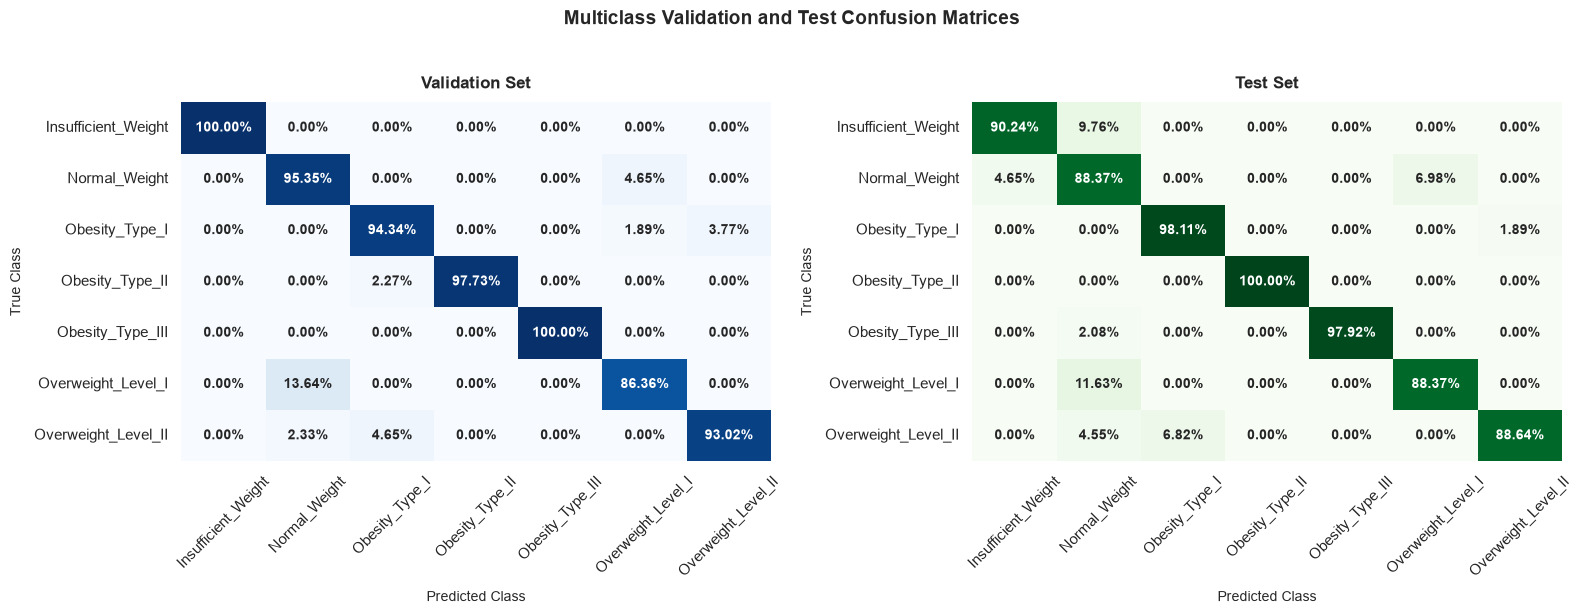


--------------------------------------------------------------------------------
-------------------------- MODEL EVALUATION COMPLETED --------------------------
--------------------------------------------------------------------------------



In [13]:
# ==============================================================================
# 1. MODEL EXTRACTION
# ==============================================================================
print("\n" + "="*80)
print(" STARTING MODEL EVALUATION ".center(80, "#"))
print("="*80 + "\n")

# Retrieve the fully trained CatBoost pipeline artifact
final_model = catboost_trainer.get_trained_model()

# ==============================================================================
# 2. MULTICLASS PREDICTIONS
# ==============================================================================
print("[EVAL] Generating predictions on validation and test datasets...")
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# ==============================================================================
# 3. VISUALIZATION (MULTICLASS CONFUSION MATRICES)
# ==============================================================================
print("[EVAL] Plotting comparative multiclass confusion matrices...")
plot_multiclass_confusion_matrices(
    y_true_valid=y_valid,
    y_pred_valid=y_pred_valid,
    y_true_test=y_test,
    y_pred_test=y_pred_test,
    mapping_df=mapping,  # Dynamically maps and sorts class IDs and names
    normalize=True       # Normalizes values to display percentages (%)
)

print("\n" + "-"*80)
print(" MODEL EVALUATION COMPLETED ".center(80, "-"))
print("-"*80 + "\n")

## Phase 8 — Train LightGBM

LightGBM requires both the multiclass objective and the number of encoded classes.

Importing LightGBMTrainer...
LightGBMTrainer instantiated successfully


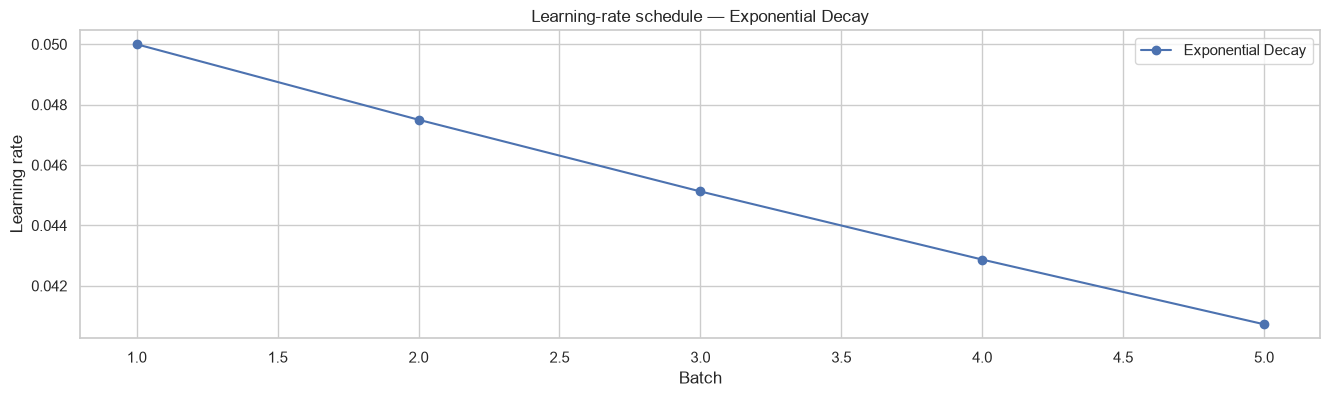

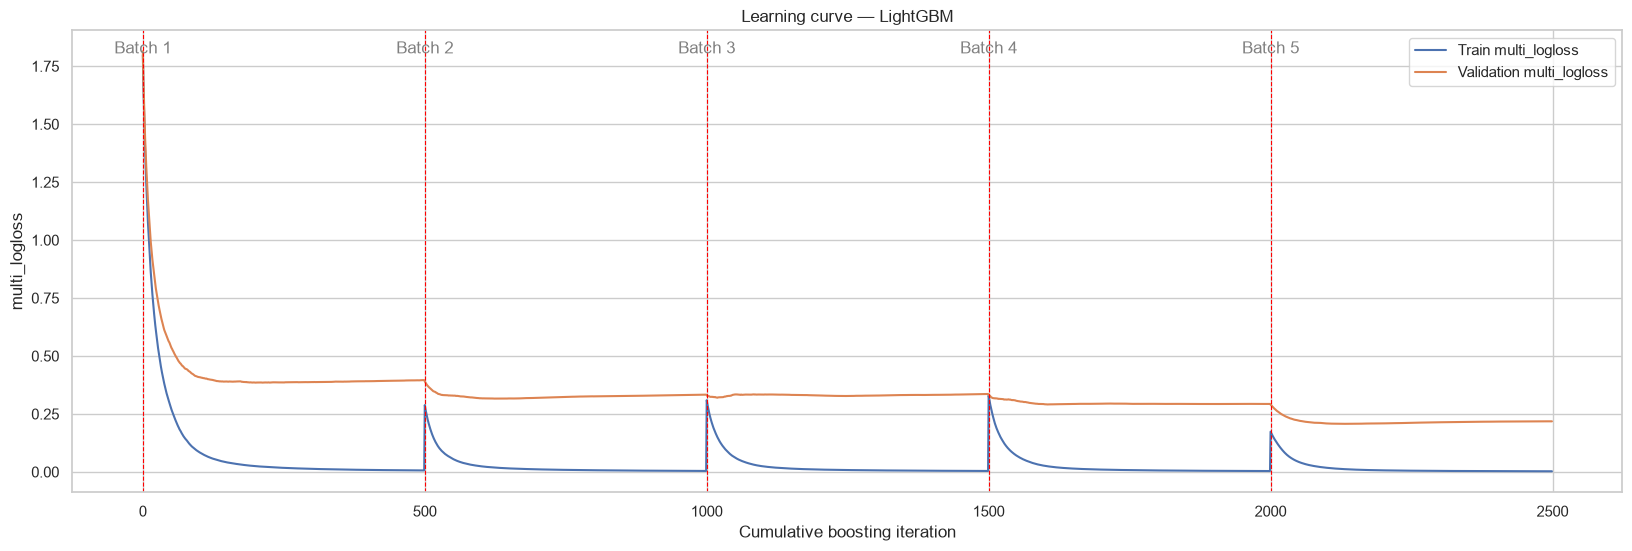

,batch,train_metric,validation_metric
0,1,0.006318,0.395817
1,2,0.004142,0.333194
2,3,0.004086,0.336102
3,4,0.003731,0.293118
4,5,0.002724,0.218121


In [14]:
print("Importing LightGBMTrainer...")
lightgbm_trainer = LightGBMTrainer()
print("LightGBMTrainer instantiated successfully")

lightgbm_trainer.fit(
    train_dataframe=spark_train_df,
    valid_dataframe=spark_validation_df,
    target_column=TARGET_COLUMN,
    model_config={
        "objective": "multiclass",
        "num_class": NUMBER_OF_CLASSES,
        "metric": "multi_logloss",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "reg_lambda": 1.0,
        "force_col_wise": True,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": RANDOM_STATE,
        "verbosity": -1,
    },
    training_config={
        **TRAINING_CONFIG,
        "max_patience": 2,
        "use_sample_weight": True,
        "show_learning_curve": True,
    },
    learning_rate_config=LEARNING_RATE_CONFIG,
)
lightgbm_model = lightgbm_trainer.get_trained_model()
display(summarize_history(lightgbm_trainer))


########################## STARTING MODEL EVALUATION ###########################

[EVAL] Generating predictions on validation and test datasets...
[EVAL] Plotting comparative multiclass confusion matrices...


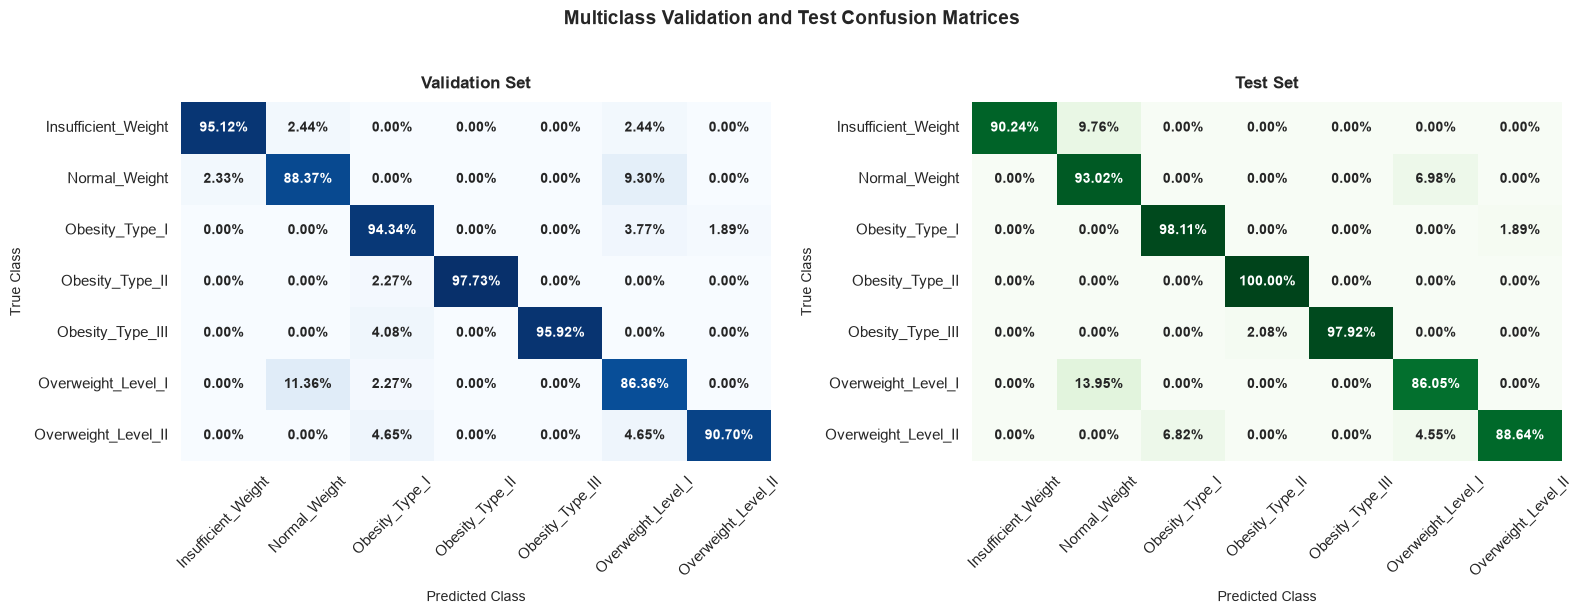


--------------------------------------------------------------------------------
-------------------------- MODEL EVALUATION COMPLETED --------------------------
--------------------------------------------------------------------------------



In [15]:
# ==============================================================================
# 1. MODEL EXTRACTION
# ==============================================================================
print("\n" + "="*80)
print(" STARTING MODEL EVALUATION ".center(80, "#"))
print("="*80 + "\n")

# Retrieve the fully trained LightGBM pipeline artifact
final_model = lightgbm_trainer.get_trained_model()

# ==============================================================================
# 2. MULTICLASS PREDICTIONS
# ==============================================================================
print("[EVAL] Generating predictions on validation and test datasets...")
y_pred_valid = final_model.predict(X_valid)
y_pred_test  = final_model.predict(X_test)

# ==============================================================================
# 3. VISUALIZATION (MULTICLASS CONFUSION MATRICES)
# ==============================================================================
print("[EVAL] Plotting comparative multiclass confusion matrices...")
plot_multiclass_confusion_matrices(
    y_true_valid=y_valid,
    y_pred_valid=y_pred_valid,
    y_true_test=y_test,
    y_pred_test=y_pred_test,
    mapping_df=mapping,  # Dynamically maps and sorts class IDs and names
    normalize=True       # Normalizes values to display percentages (%)
)

print("\n" + "-"*80)
print(" MODEL EVALUATION COMPLETED ".center(80, "-"))
print("-"*80 + "\n")

## Phase 9 — Final Multiclass Model Comparison

The test set is used here to perform the final model evaluation. To streamline the process, we use the unified `evaluate_multiclass_models` function to evaluate our three trained champions (**XGBoost**, **CatBoost**, and **LightGBM**) side-by-side on both the validation and test datasets.

For each model, this pipeline will:
1. **Generate multiclass predictions** on top of validation and test datasets.
2. **Dynamically map and sort** class IDs and human-readable names using our reference mapping DataFrame.
3. **Plot comparative confusion matrices** normalized to percentages (%) to visually assess recall and misclassifications across all target classes.

```python
# Group your trained pipelines into a dictionary
trained_pipelines = {
    "XGBoost": xgboost_trainer.get_trained_model(),
    "CatBoost": catboost_trainer.get_trained_model(),
    "LightGBM": lightgbm_trainer.get_trained_model()
}

# Run the unified multiclass evaluation pipeline
evaluate_multiclass_models(
    models_dict=trained_pipelines,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test,
    mapping_df=mapping
)

In [16]:
def evaluate_multiclass_models(models_dict, X_valid, y_valid, X_test, y_test, mapping_df):
    """
    Loops through trained models, generates multi-class predictions, 
    and plots comparative confusion matrices using a dynamic class mapping.
    """
    for model_name, model_obj in models_dict.items():
        print("\n" + "="*80)
        print(f" STARTING EVALUATION FOR: {model_name.upper()} ".center(80, "#"))
        print("="*80)
        
        # 1. MODEL PREDICTIONS
        print(f"[{model_name.upper()}] Step 1: Generating multi-class predictions on Validation and Test sets...")
        y_pred_valid = model_obj.predict(X_valid)
        y_pred_test  = model_obj.predict(X_test)
        
        # 2. VISUALIZATION (MULTICLASS CONFUSION MATRICES)
        print(f"[{model_name.upper()}] Step 2: Plotting comparative multiclass confusion matrices...")
        plot_multiclass_confusion_matrices(
            y_true_valid=y_valid,
            y_pred_valid=y_pred_valid,
            y_true_test=y_test,
            y_pred_test=y_pred_test,
            mapping_df=mapping_df,  # Dynamically maps and sorts class IDs and names
            normalize=True          # Normalizes values to display percentages (%)
        )
        
        print(f" {'FINISHED ' + model_name.upper() + ' EVALUATION'} ".center(80, "-"))
        print("\n")


####################### STARTING EVALUATION FOR: XGBOOST #######################
[XGBOOST] Step 1: Generating multi-class predictions on Validation and Test sets...
[XGBOOST] Step 2: Plotting comparative multiclass confusion matrices...


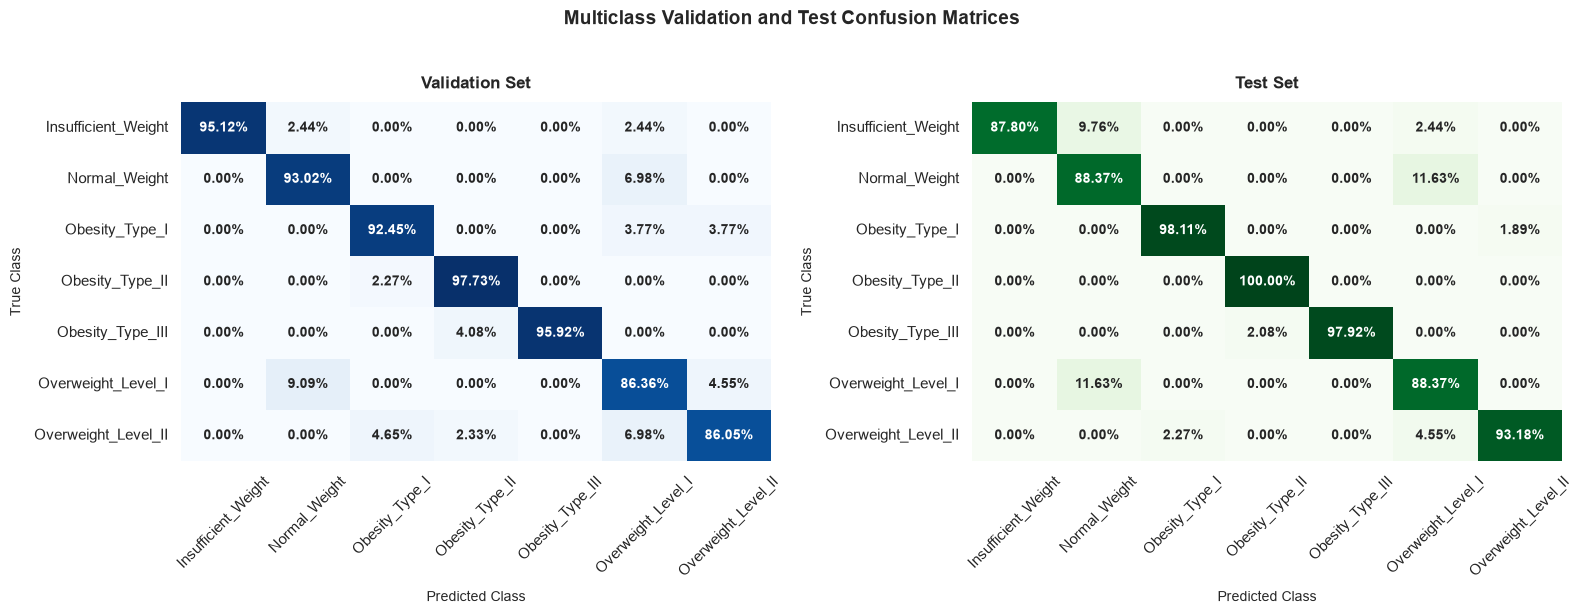

------------------------- FINISHED XGBOOST EVALUATION --------------------------



###################### STARTING EVALUATION FOR: CATBOOST #######################
[CATBOOST] Step 1: Generating multi-class predictions on Validation and Test sets...
[CATBOOST] Step 2: Plotting comparative multiclass confusion matrices...


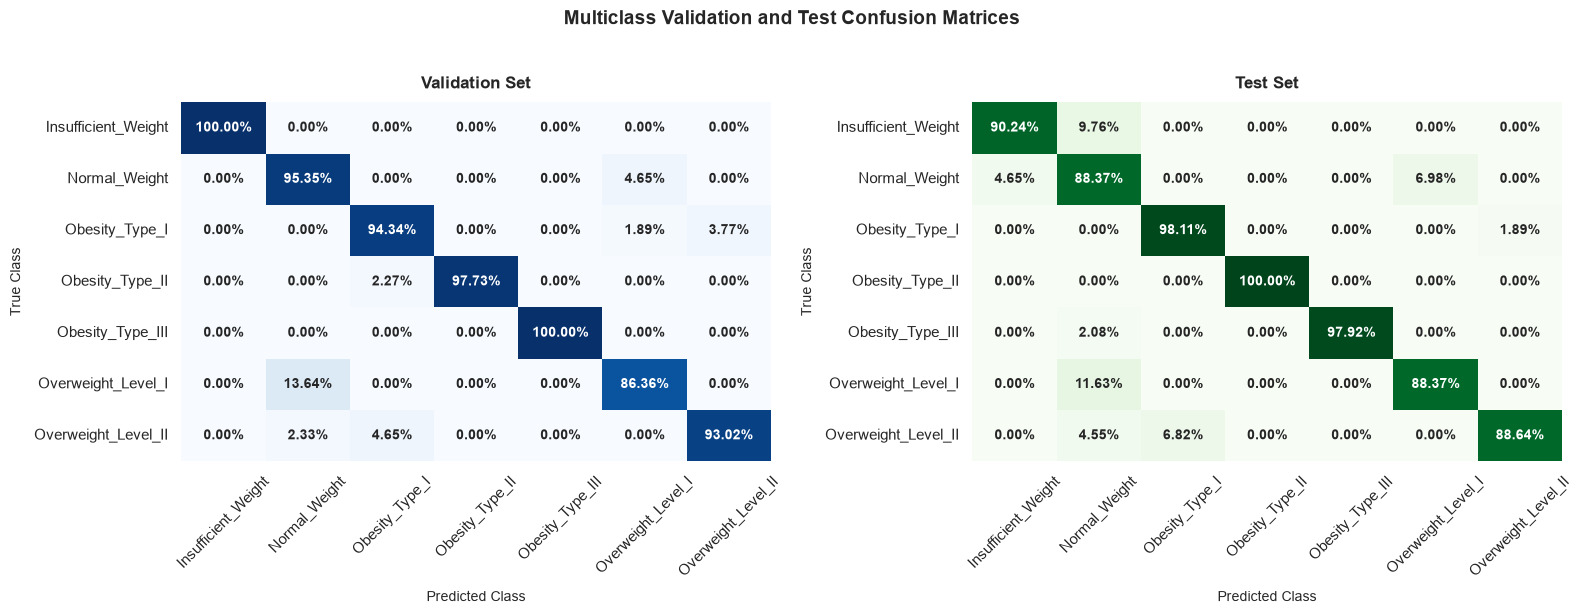

------------------------- FINISHED CATBOOST EVALUATION -------------------------



###################### STARTING EVALUATION FOR: LIGHTGBM #######################
[LIGHTGBM] Step 1: Generating multi-class predictions on Validation and Test sets...
[LIGHTGBM] Step 2: Plotting comparative multiclass confusion matrices...


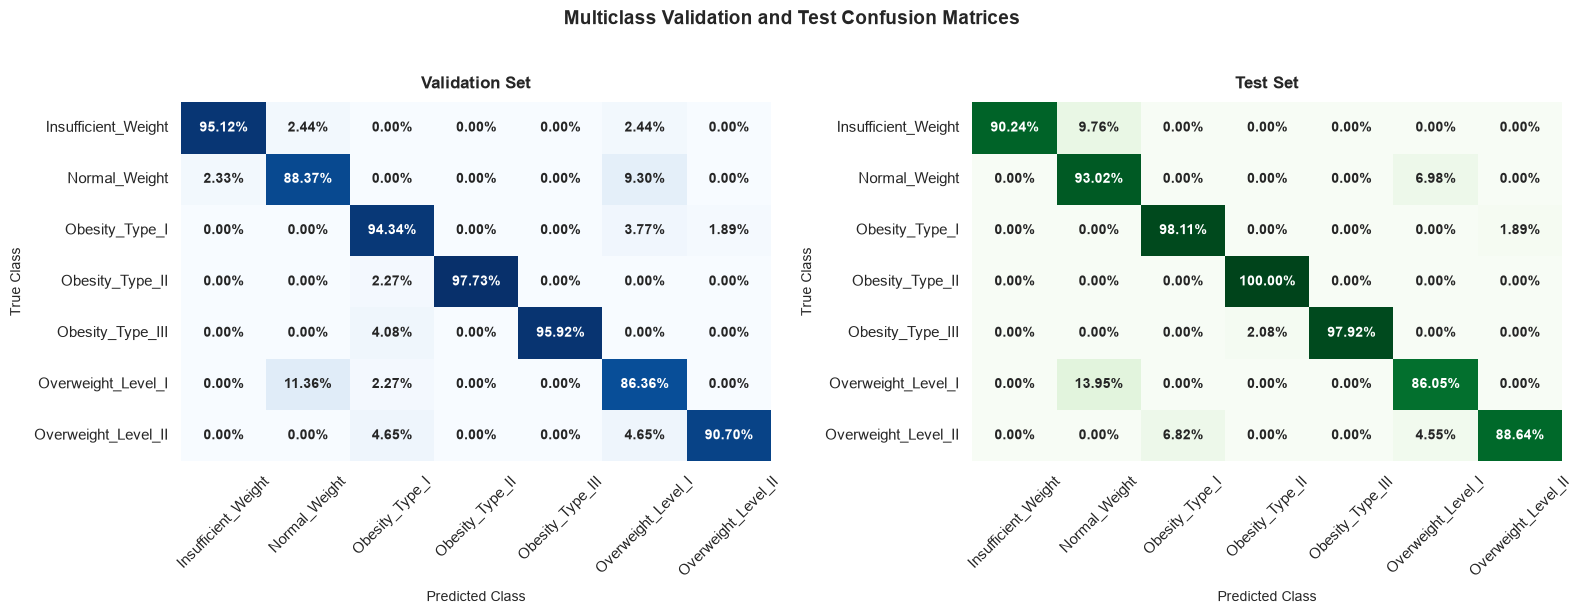

------------------------- FINISHED LIGHTGBM EVALUATION -------------------------




In [17]:
# ==============================================================================
# MULTICLASS MODELS EVALUATION PIPELINE
# ==============================================================================

# Group your trained pipelines into a dictionary
trained_pipelines = {
    "XGBoost": xgboost_trainer.get_trained_model(),
    "CatBoost": catboost_trainer.get_trained_model(),
    "LightGBM": lightgbm_trainer.get_trained_model()
}

# Run the unified multiclass evaluation pipeline
evaluate_multiclass_models(
    models_dict=trained_pipelines,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test,
    mapping_df=mapping
)

## Phase 10 — Resource cleanup

In [18]:
spark.stop()